# Tracking Political Change with Embeddings of Parliamentary Speeches
***
# Data Cleaning and Exploratory Analysis

In [ ]:
# Imports and Paths
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Toggle: strip common openings from the beginning of each speech
TRIM_OPENINGS = True

In [ ]:
# Load the raw data
speeches = pd.read_csv("speeches.csv")
ches = pd.read_csv("CHES.csv")

# Auxiliary Open Discourse table
factions = pd.read_csv("factions.csv")

print("speeches:", speeches.shape)
print("ches:", ches.shape)

speeches: (907644, 12)
ches: (1441, 90)


## 1. Data Loading and Cleanup
### 1.1 Speeches dataset

In [ ]:
# Parse dates and filter for the main analysis window
speeches["date"] = pd.to_datetime(speeches["date"], errors="coerce")

START, END = "2000-01-01", "2021-12-31"
speeches = speeches[(speeches["date"] >= START) & (speeches["date"] <= END)].copy()

print(f"{len(speeches):,} speeches ({START} to {END})")

303,199 speeches (2000-01-01 to 2021-12-31)


In [ ]:
# Ignore unmatched factions (-1): chairing turns, ministerial statements, guests
# Also drop rows with politicianId == -1
speeches = speeches[(speeches["factionId"] != -1) & (speeches["politicianId"] != -1)].copy()
print(f"{len(speeches):,} speeches remain after dropping factionId / politicianId == -1")

135,057 speeches remain after dropping factionId / politicianId == -1


In [ ]:
# Text cleaning: Take out interjection markers, PDF's line wrapping, orphan dashes and spaces
_INTERJECTION_MARKER = re.compile(r"\(\{\d+\}\)")
_PARAGRAPH_BREAK     = re.compile(r"\n{2,}")
_HYPHEN_LINEBREAK    = re.compile(r"-\n(?=\w)")
_SOFT_LINEBREAK      = re.compile(r"\s*\n\s*")
_MULTI_SPACE         = re.compile(r"\s{2,}")
_EDGE_DASHES         = re.compile(r"^[-–—\s]+|[-–—\s]+$")
_HAS_WORD            = re.compile(r"\w")

def clean_text(text: str) -> str:
    text = _INTERJECTION_MARKER.sub("", text)

    parts = []
    for para in _PARAGRAPH_BREAK.split(text):
        para = _HYPHEN_LINEBREAK.sub("", para)
        para = _SOFT_LINEBREAK.sub(" ", para)
        para = _EDGE_DASHES.sub("", para)
        para = _MULTI_SPACE.sub(" ", para).strip()
        if para and _HAS_WORD.search(para):
            parts.append(para)
    return " ".join(parts)

speeches["speechContent"] = speeches["speechContent"].fillna("").map(clean_text)
empty_after = (speeches["speechContent"] == "").sum()
print(f"cleaned {len(speeches):,} speeches ({empty_after} empty after cleaning)")

cleaned 135,057 speeches (15 empty after cleaning)


In [ ]:
# Optional: strip common parliamentary openings so the embedding model does not see the same salutation at the start of most speeches
_OPENING_PATTERNS = [
    r"sehr geehrte damen und herren",
    r"meine (?:sehr geehrten )?damen und herren",
    r"sehr geehrter herr präsident",
    r"sehr geehrte frau präsidentin",
    r"herr präsident",
    r"frau präsidentin",
    r"liebe kolleginnen und kollegen",
    r"werte kolleginnen und kollegen",
]
_OPENING_RE = re.compile(
    r"^(?:(?:" + "|".join(_OPENING_PATTERNS) + r")[\s,.!;:–—-]*)+",
    re.IGNORECASE,
)

def trim_opening(text: str) -> str:
    return _OPENING_RE.sub("", text, count=1).lstrip()

if TRIM_OPENINGS:
    before = speeches["speechContent"].str.len().sum()
    speeches["speechContent"] = speeches["speechContent"].map(trim_opening)
    after = speeches["speechContent"].str.len().sum()
    print(f"trimmed openings — {before - after:,} chars removed "
          f"({(before - after) / before:.2%})")
else:
    print("TRIM_OPENINGS = False")

trimmed openings — 2,638,615 chars removed (0.60%)


In [ ]:
# Tokenize with the Jina v3 multilingual tokenizer (XLM-R based, 8192 ctx) so the length distribution reflects the exact units the model will see
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)
print(f"Tokenizer max length: {tok.model_max_length}\n")

BATCH = 256

def _token_lengths(texts):
    out = []
    for i in range(0, len(texts), BATCH):
        enc = tok(texts[i:i + BATCH], add_special_tokens=True,
                  truncation=False, padding=False)
        out.extend(len(x) for x in enc["input_ids"])
    return out

print(f"Tokenizing {len(speeches):,} speeches…")
speeches["n_tokens"] = _token_lengths(speeches["speechContent"].fillna("").tolist())
print(f"  done — n_tokens: min={speeches['n_tokens'].min()}, "
      f"median={int(speeches['n_tokens'].median())}, max={speeches['n_tokens'].max()}")

`torch_dtype` is deprecated! Use `dtype` instead!


Tokenizer max length: 8194

Tokenizing 135,057 speeches…


Token indices sequence length is longer than the specified maximum sequence length for this model (9437 > 8194). Running this sequence through the model will result in indexing errors


  done — n_tokens: min=2, median=669, max=9437


In [ ]:
# Full length distribution
print(speeches["n_tokens"].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

count    135057.000000
mean        713.881591
std         652.041064
min           2.000000
1%            4.000000
5%           10.000000
10%          33.000000
25%         116.000000
50%         669.000000
75%        1122.000000
90%        1533.000000
95%        1851.000000
99%        2568.440000
max        9437.000000
Name: n_tokens, dtype: float64


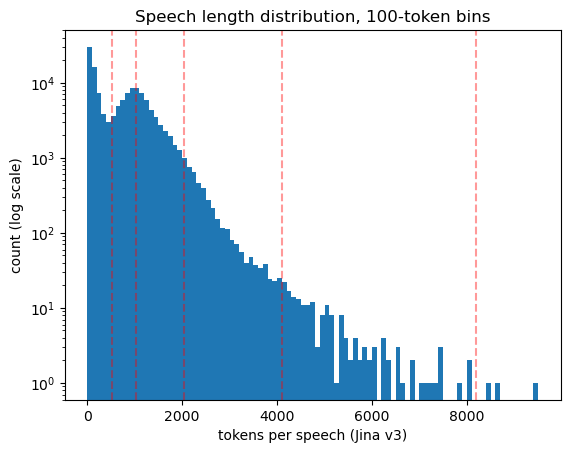


Share of speeches below threshold:
under   10 tokens:  4.7%
under   15 tokens:  6.2%
under   20 tokens:  7.4%
under   30 tokens:  9.3%
under   50 tokens: 13.0%
under  100 tokens: 22.3%
under  200 tokens: 34.3%
under  500 tokens: 44.8%


In [ ]:
# Histogram of speech lengths with common model context caps marked
top = speeches["n_tokens"].max()
plt.hist(speeches["n_tokens"], bins=range(0, top + 100, 100))
plt.yscale("log")
plt.xlabel("tokens per speech (Jina v3)"); plt.ylabel("count (log scale)")
plt.title("Speech length distribution, 100-token bins")
for cap in [512, 1024, 2048, 4096, 8192]:
    plt.axvline(cap, color="red", linestyle="--", alpha=0.4)
plt.show()

print("\nShare of speeches below threshold:")
for t in [10, 15, 20, 30, 50, 100, 200, 500]:
    print(f"under {t:>4} tokens: {(speeches['n_tokens'] < t).mean():5.1%}")

In [ ]:
# Examples of very short speeches (< 30 tokens) (mostly interjections / procedural)
short = speeches.loc[speeches["n_tokens"] < 30, ["n_tokens", "speechContent"]]
print(f"{len(short):,} speeches under 30 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

12,579 speeches under 30 tokens

[1] (7 tokens) 'Ja, bitte sehr.'
--------------------------------------------------------------------------------
[2] (14 tokens) 'Es ist mir eine Ehre, Herr Abgeordneter.'
--------------------------------------------------------------------------------
[3] (9 tokens) 'Die habe ich noch nicht bekommen!'
--------------------------------------------------------------------------------
[4] (4 tokens) 'Bitte.'
--------------------------------------------------------------------------------
[5] (8 tokens) 'Gerne, Frau Präsidentin.'
--------------------------------------------------------------------------------
[6] (6 tokens) 'Bitte, natürlich.'
--------------------------------------------------------------------------------
[7] (28 tokens) 'Frau Staatssekretärin, bedeutet das, dass neue AfA-Tabellen in diesem Jahr nicht mehr in Kraft treten werden?'
--------------------------------------------------------------------------------
[8] (4 tokens) 'Bitte.'
----

In [ ]:
# Examples in the 30–50 token band (a bit more substantive, still short)
short = speeches.loc[
    (speeches["n_tokens"] >= 30) & (speeches["n_tokens"] < 50),
    ["n_tokens", "speechContent"],
]
print(f"{len(short):,} speeches between 30 and 50 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

4,953 speeches between 30 and 50 tokens

[1] (49 tokens) 'Herr Staatssekretär, wird denn nach den neuen Richtlinien der deutsch-französische Hubschrauber „Tiger“ an die Türkei zu Testzwecken geliefert oder würde er nach den neuen Kriterien nicht mehr geliefert?'
--------------------------------------------------------------------------------
[2] (38 tokens) 'Müssten Sie, wenn Sie das Volumen von 14 Milliarden DM auf 3, 4 oder 5 Milliarden DM herunterschrauben wollen, nicht neue Tabellen erarbeiten?'
--------------------------------------------------------------------------------
[3] (43 tokens) 'Wird untersucht und rechtlich stringent verfolgt, was im Rahmen der Möglichkeiten der Arbeitsverwaltung - das Unternehmen in Haftung und dafür Konkursausfallgelder in Anspruch zu nehmen - unternommen werden kann?'
--------------------------------------------------------------------------------
[4] (35 tokens) 'bevor diese vom Bundesverfassungsgericht einkassiert wird und bevor Sie dem Wirtschaf

In [ ]:
# Examples in the 50–100 token band (borderline for the < 100 min-length cut-off)
short = speeches.loc[
    (speeches["n_tokens"] >= 50) & (speeches["n_tokens"] < 100),
    ["n_tokens", "speechContent"],
]
print(f"{len(short):,} speeches between 50 and 100 tokens\n")

for i, (n, txt) in enumerate(short.head(15).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

12,565 speeches between 50 and 100 tokens

[1] (68 tokens) 'Herr Staatssekretär, welche Auswirkungen haben die restriktiven Rüstungsexportrichtlinien auf die deutsche Industrie? In welchem Umfang können davon Arbeitsplätze betroffen sein? Wie bewertet die Bundesregierung den Umstand, dass durch die Neuregelung Kernfähigkeiten der deutschen Rüstungsindustrie unwiederbringlich verloren gehen können?'
--------------------------------------------------------------------------------
[2] (71 tokens) 'Herr Staatssekretär, beurteile ich es richtig, dass nach dem, was Sie jetzt vorgetragen haben, die Türkei - den Fall kennen wir alle nicht nur den Testpanzer bekommen konnte, sondern demnächst auch, wenn sie sie bestellt, diese Panzer erhalten würde? Oder gibt es nach diesen Richtlinien Bedenken?'
--------------------------------------------------------------------------------
[3] (98 tokens) 'In diesem Zusammenhang eine weitere Frage. Ich habe kürzlich an einer Veranstaltung teilgenommen, bei d

In [ ]:
# Exact truncation shares per model context cap
for cap in [512, 1024, 2048, 4096, 8192]:
    over = speeches["n_tokens"] > cap
    lost_tokens = (speeches.loc[over, "n_tokens"] - cap).sum()
    total_tokens = speeches["n_tokens"].sum()
    print(f"{cap:>5} token cap: {over.mean():>5.1%} speeches truncated "
          f"({over.sum():>6,}), {lost_tokens / total_tokens:>5.1%} of all tokens dropped")

  512 token cap: 54.9% speeches truncated (74,131), 52.0% of all tokens dropped
 1024 token cap: 31.0% speeches truncated (41,842), 19.9% of all tokens dropped
 2048 token cap:  3.2% speeches truncated ( 4,277),  2.4% of all tokens dropped
 4096 token cap:  0.1% speeches truncated (   185),  0.2% of all tokens dropped
 8192 token cap:  0.0% speeches truncated (     3),  0.0% of all tokens dropped


In [ ]:
# Drop short interjections and procedural remarks
MIN_TOKENS = 100
speeches = speeches[speeches["n_tokens"] >= MIN_TOKENS].copy()
print(f"{len(speeches):,} speeches after dropping < {MIN_TOKENS} tokens")

104,960 speeches after dropping < 100 tokens


In [ ]:
# Truncate any remaining speeches longer than the Jina v3 context (8192 tokens)
CAP = 8192

def _truncate_to_cap(text):
    ids = tok.encode(text, add_special_tokens=False,
                     truncation=True, max_length=CAP)
    return tok.decode(ids, skip_special_tokens=True)

long_mask = speeches["n_tokens"] > CAP
print(f"truncating {long_mask.sum()} speeches (> {CAP} tokens) to {CAP} tokens")

speeches.loc[long_mask, "speechContent"] = (
    speeches.loc[long_mask, "speechContent"].apply(_truncate_to_cap)
)
if long_mask.any():
    new_ids = tok(speeches.loc[long_mask, "speechContent"].tolist(),
                  add_special_tokens=True, truncation=False,
                  padding=False)["input_ids"]
    speeches.loc[long_mask, "n_tokens"] = [len(x) for x in new_ids]

print(f"max tokens after truncation = {speeches['n_tokens'].max()}")

truncating 3 speeches (> 8192 tokens) to 8192 tokens
max tokens after truncation = 8194


In [ ]:
# Standardise party and politician names, then attach year / year_month for later grouping
# Party names: merge in the human-readable abbreviation from factions.csv, then rename inconsistent labels
# Politician names: strip whitespace and build a combined `politicianName` column for display
faction_names = factions.rename(columns={"id": "factionId", "abbreviation": "party"})

PARTY_RENAME = {
    "DIE LINKE.": "LINKE",
}

speeches = speeches.merge(faction_names[["factionId", "party"]], on="factionId", how="left")
speeches["party"] = speeches["party"].replace(PARTY_RENAME)

speeches["firstName"] = speeches["firstName"].fillna("").str.strip()
speeches["lastName"]  = speeches["lastName"].fillna("").str.strip()
speeches["politicianName"] = (speeches["firstName"] + " " + speeches["lastName"]).str.strip()

speeches["year"] = speeches["date"].dt.year
speeches["year_month"] = speeches["date"].dt.to_period("M").astype(str)

### 1.2 Unit of analysis

MP-year is our chosen unit. Single speeches are too noisy (dominated by the day's topic); MP-month is too sparse (most MPs don't speak enough per month); MP-year has enough text per cell for a stable average.

In [ ]:
# How much text lands in each cell under each candidate unit?
per_mp_year  = speeches.groupby(["politicianId", "year"]).size()
per_mp_month = speeches.groupby(["politicianId", "year_month"]).size()

print(f"Median speeches per MP-year : {per_mp_year.median():.0f}")
print(f"Median speeches per MP-month: {per_mp_month.median():.0f}")
print(f"MP-months with fewer than 3 speeches: {(per_mp_month < 3).mean():.0%}")

### 1.3 Chapel Hill Expert Survey dataset

In [ ]:
ches_de = ches[ches["country"] == 3].copy()

CHES_COLS = ["year", "party_id", "party", "lrgen"]
ches_de = ches_de[CHES_COLS].sort_values(["party", "year"]).reset_index(drop=True)

print(f"CHES Germany rows: {len(ches_de)}")
print(f"Years available: {sorted(ches_de['year'].unique())}")
ches_de.head()

CHES Germany rows: 54
Years available: [np.int64(1999), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2019), np.int64(2024)]


,year,party_id,party,lrgen
0,2014,310,AfD,8.923077
1,2019,310,AfD,9.238095
2,2024,310,AfD,9.263158
3,2024,313,BSW,3.625000
4,1999,301,CDU,5.866667


### 1.4 Events

For the event-study part of the analysis we focus on four external shocks that fall inside the 2000–2021 window and could leave a trace in parliamentary discourse:

- **9/11** (terrorist attacks on the United States)
- **Lehman Brothers collapse** (trigger of the global financial crisis)
- **Fukushima nuclear disaster** (reactor accident following an earthquake)
- **Migration crisis / Cologne New Year's Eve** (sexual assaults on the night of 31 December 2015 / 1 January 2016, at the peak of the 2015–16 refugee inflow)

## 2. Exploratory analysis
### 2.1 Politicians & parties

In [ ]:
# Unique MPs per party, activity per MP and party switchers
# Switcher = an MP who appears under more than one party during the window.
mps_per_party = (speeches.groupby("party")["politicianId"].nunique()
                 .rename("unique_MPs"))
speeches_per_party = speeches["party"].value_counts().rename("n_speeches")
per_party = pd.concat([mps_per_party, speeches_per_party], axis=1)
per_party["speeches_per_MP"] = (per_party["n_speeches"] / per_party["unique_MPs"]).round(1)
per_party = per_party.sort_values("n_speeches", ascending=False)
print("Unique MPs and speeches per party:")
print(per_party)

party_per_mp = speeches.groupby("politicianId")["party"].nunique()
switchers = party_per_mp[party_per_mp > 1].index
print(f"\nTotal unique MPs in the corpus: {speeches['politicianId'].nunique():,}")
print(f"MPs who spoke under more than one party (switchers): {len(switchers)}")

Unique MPs and speeches per party:
              unique_MPs  n_speeches  speeches_per_MP
party                                                
CDU/CSU              602       31043             51.6
SPD                  531       23329             43.9
Grüne                156       18345            117.6
LINKE                129       13485            104.5
FDP                  198       13282             67.1
AfD                   92        3496             38.0
PDS                   37        1361             36.8
Fraktionslos          12         619             51.6

Total unique MPs in the corpus: 1,735
MPs who spoke under more than one party (switchers): 20


### 2.2 Speeches

#### Total speeches per party

Total speeches per party (2000–2021):
party
CDU/CSU         31043
SPD             23329
Grüne           18345
LINKE           13485
FDP             13282
AfD              3496
PDS              1361
Fraktionslos      619
Name: count, dtype: int64


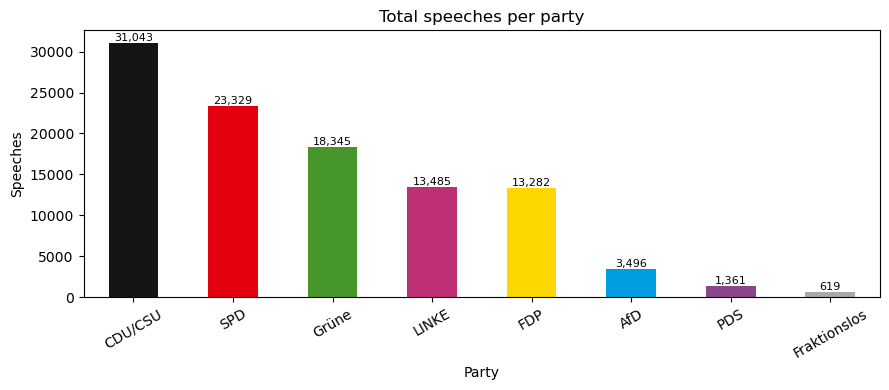

In [ ]:
# Total speeches per party across the whole window
party_colors = {
    "CDU/CSU":      "#151518",
    "SPD":          "#E3000F",
    "Grüne":        "#46962B",
    "FDP":          "#FFD700",
    "AfD":          "#009EE0",
    "LINKE":        "#BE3075",
    "PDS":          "#8B4789",
    "Fraktionslos": "#AAAAAA",
}

party_counts = speeches["party"].value_counts()
print(f"Total speeches per party ({int(speeches['year'].min())}–{int(speeches['year'].max())}):")
print(party_counts)

fig, ax = plt.subplots(figsize=(9, 4))
party_counts.plot(
    kind="bar", ax=ax,
    color=[party_colors.get(p, "steelblue") for p in party_counts.index],
)
ax.set_ylabel("Speeches"); ax.set_xlabel("Party")
ax.set_title("Total speeches per party")
for i, v in enumerate(party_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

#### Speech length by party

Speech length by party (tokens and words):
             n_tokens                n_words              
                 mean  median    std    mean median    std
party                                                     
CDU/CSU        1020.0  1005.0  664.8   659.7  650.0  431.0
SPD            1019.1  1007.0  635.1   661.7  654.0  413.6
PDS             846.9   867.0  566.8   538.6  550.0  362.4
FDP             836.9   822.0  544.7   540.9  532.0  352.4
LINKE           773.0   796.0  561.7   489.8  499.0  358.2
Grüne           764.2   767.0  573.5   492.4  491.0  372.1
AfD             743.5   797.0  385.0   466.0  498.5  240.6
Fraktionslos    630.9   663.0  336.4   401.5  415.0  214.6


/var/folders/s5/fy91nyld24n09t7z3kdvvvzh0000gn/T/ipykernel_97054/1622405177.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


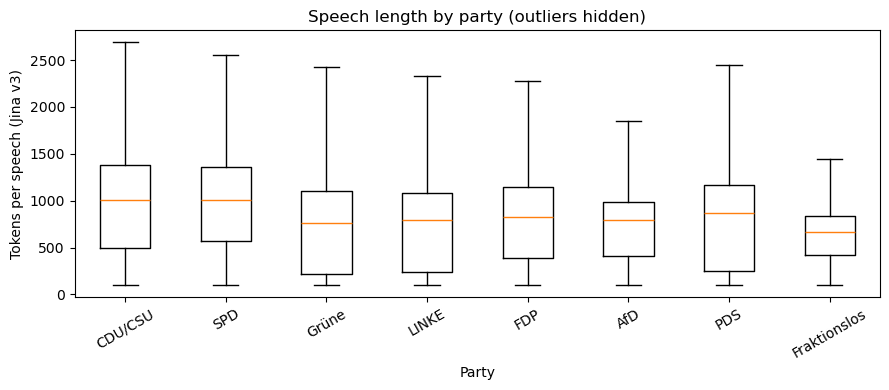

In [ ]:
# Speech length by party: token counts (Jina v3 tokenizer) and word counts
_word_re_len = re.compile(r"[A-Za-zÄÖÜäöüß]+")
speeches["n_words"] = speeches["speechContent"].str.count(_word_re_len.pattern)

length_summary = (speeches.groupby("party")[["n_tokens", "n_words"]]
                  .agg(["mean", "median", "std"])
                  .round(1)
                  .sort_values(("n_tokens", "mean"), ascending=False))
print("Speech length by party (tokens and words):")
print(length_summary)

order = speeches["party"].value_counts().index.tolist()
data = [speeches.loc[speeches["party"] == p, "n_tokens"].values for p in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel("Tokens per speech (Jina v3)")
ax.set_xlabel("Party")
ax.set_title("Speech length by party (outliers hidden)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

#### Vocabulary per party

In [ ]:
# Raw type-token ratio (TTR) shrinks with corpus size, so a party with more text looks less "diverse" for purely statistical reasons
# To make parties comparable, we also report a sampled TTR computed on an equal-size random draw of word tokens per party
_word_re_vocab = re.compile(r"[A-Za-zÄÖÜäöüß]+")
rng = np.random.default_rng(24)

tokens_by_party = {}
for party, group in speeches.groupby("party"):
    all_tokens = []
    for text in group["speechContent"]:
        all_tokens.extend(w.lower() for w in _word_re_vocab.findall(text))
    tokens_by_party[party] = all_tokens

SAMPLE = min(len(v) for v in tokens_by_party.values())
print(f"Sample size for length-controlled TTR: {SAMPLE:,} word tokens per party.\n")

rows = []
for party, toks in tokens_by_party.items():
    sample = rng.choice(toks, size=SAMPLE, replace=False)
    rows.append({
        "party": party,
        "tokens": len(toks),
        "types": len(set(toks)),
        "ttr_raw": round(len(set(toks)) / len(toks), 4),
        "ttr_sampled": round(len(set(sample)) / SAMPLE, 4),
    })

vocab = (pd.DataFrame(rows).set_index("party")
         .sort_values("tokens", ascending=False))
print(vocab)

Sample size for length-controlled TTR: 248,515 word tokens per party.

                tokens   types  ttr_raw  ttr_sampled
party                                               
CDU/CSU       20478452  271821   0.0133       0.1033
SPD           15436224  231102   0.0150       0.1020
Grüne          9032712  179779   0.0199       0.1039
FDP            7183577  153132   0.0213       0.1018
LINKE          6605057  153091   0.0232       0.1077
AfD            1629261   79935   0.0491       0.1147
PDS             732975   45349   0.0619       0.1014
Fraktionslos    248515   23937   0.0963       0.0963


#### Missing data

In [ ]:
# Missingness across the columns we are interested in (main focus on speechContent)
KEY_COLS = ["speechContent", "politicianId", "factionId", "party",
            "date", "positionShort"]

n = len(speeches)
missing = pd.DataFrame({
    "n_missing": speeches[KEY_COLS].isna().sum().astype(int),
    "share":     (speeches[KEY_COLS].isna().mean()).round(4),
})
print(f"Missingness in the cleaned corpus ({n:,} speeches):")
print(missing)

empty_text = (speeches["speechContent"].fillna("").str.strip() == "").sum()
print(f"\nRows with empty speechContent: {empty_text}")

# For context, we see how many raw Open Discourse rows carried the -1 sentinel in the key IDs before we dropped them
_raw_ids = pd.read_csv("speeches.csv",
                       usecols=["politicianId", "factionId"])
raw_n = len(_raw_ids)
print(f"\nRaw Open Discourse dump ({raw_n:,} rows, before any filter):")
print(f"  factionId    == -1: {(_raw_ids['factionId']    == -1).sum():>7,}  "
      f"({(_raw_ids['factionId']    == -1).mean():.1%})")
print(f"  politicianId == -1: {(_raw_ids['politicianId'] == -1).sum():>7,}  "
      f"({(_raw_ids['politicianId'] == -1).mean():.1%})")

Missingness in the cleaned corpus (104,960 speeches):
               n_missing  share
speechContent          0    0.0
politicianId           0    0.0
factionId              0    0.0
party                  0    0.0
date                   0    0.0
positionShort          0    0.0

Rows with empty speechContent: 0

Raw Open Discourse dump (907,644 rows, before any filter):
  factionId    == -1: 533,568  (58.8%)
  politicianId == -1:  38,009  (4.2%)


### 2.3 Trends over time

#### Speeches per party over time

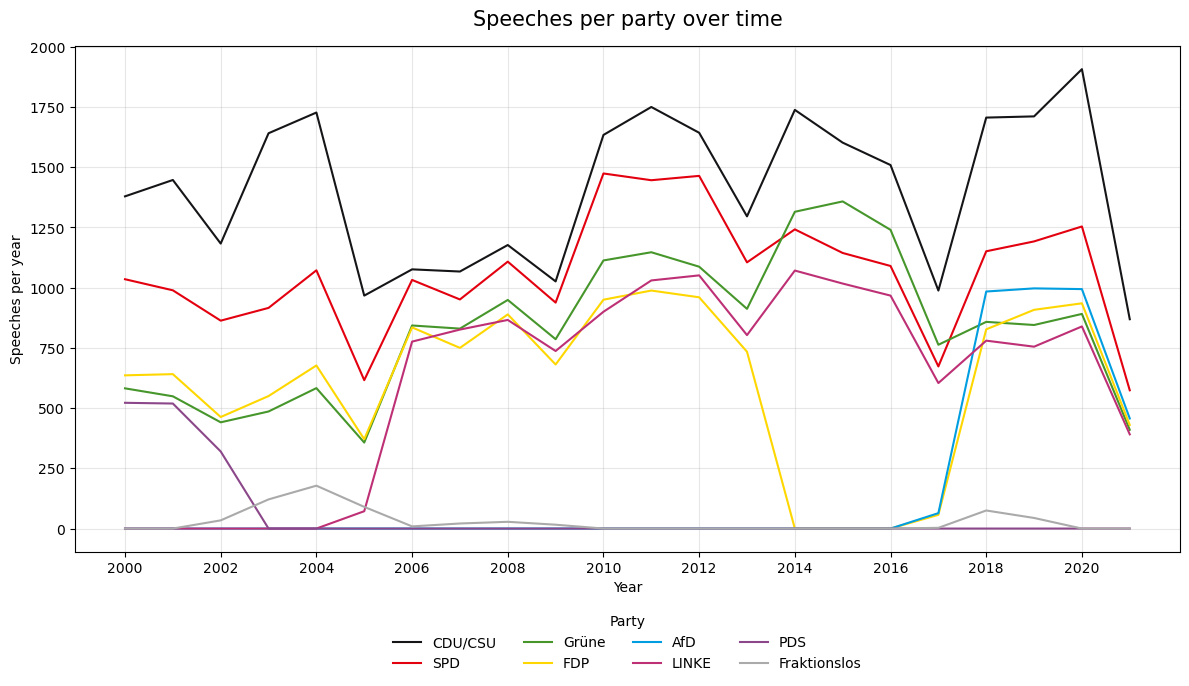

In [ ]:
# Speeches per party per year
per_year_party = (speeches.groupby(["year", "party"]).size()
                  .unstack("party").fillna(0))
per_year_party = per_year_party[[p for p in party_colors if p in per_year_party.columns]]

fig, ax = plt.subplots(figsize=(12, 7))
per_year_party.plot(
    ax=ax,
    color=[party_colors[c] for c in per_year_party.columns],
)
ax.set_ylabel("Speeches per year")
ax.set_xlabel("Year")
ax.set_title("Speeches per party over time", fontsize=15, pad=15)
ax.set_xticks(range(int(per_year_party.index.min()),
                    int(per_year_party.index.max()) + 1, 2))
ax.legend(title="Party", loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

#### Topic frequency over time (keyword proxy)

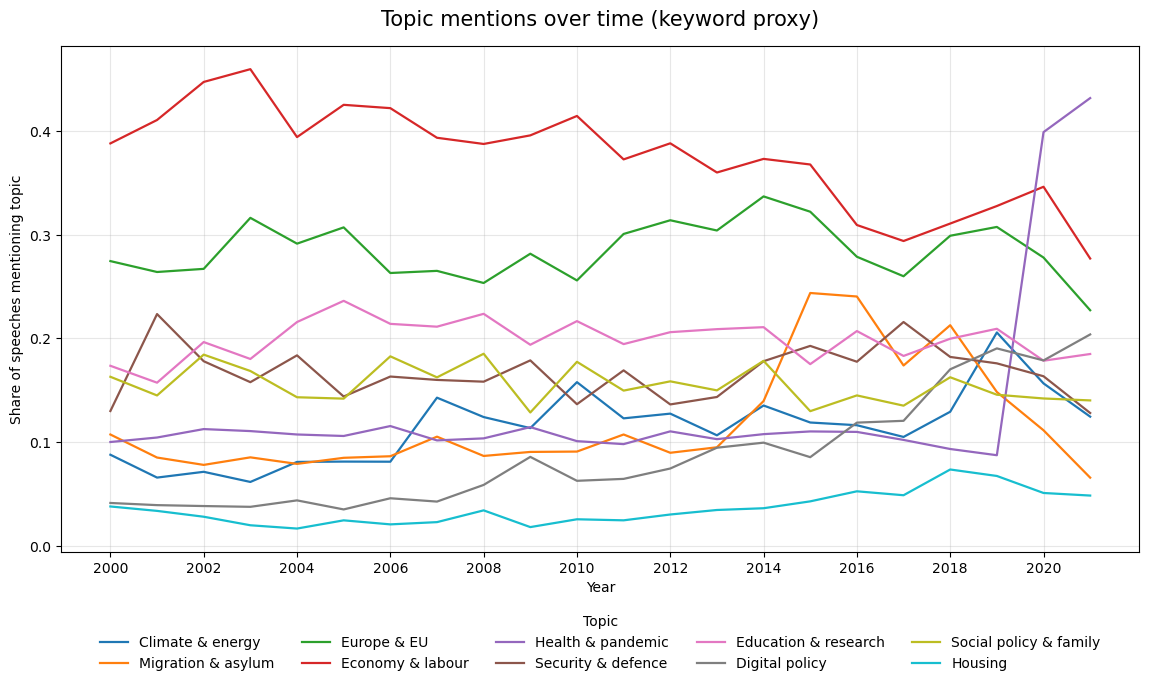

In [ ]:
# Keyword-based topic frequency over time (only a first-pass proxy, NOT a topic model)
topics = {
    "Climate & energy":       ["klima", "energiewende", "erneuerbar", "kohleausstieg",
                                "kohlekraft", "atomkraft", "atomausstieg", "emission",
                                "solar", "windkraft"],
    "Migration & asylum":     ["migration", "migrant", "flüchtling", "flucht", "asyl",
                                "geflüchtet", "einwander", "integration", "abschiebung"],
    "Europe & EU":            ["europ", "brüssel", "brexit", "eurozone", "euro-krise"],
    "Economy & labour":       ["wirtschaft", "arbeitsmarkt", "arbeitslos", "inflation",
                                "konjunktur", "mindestlohn", "tarif"],
    "Health & pandemic":      ["gesundheit", "pandemie", "corona", "covid", "lockdown",
                                "impfung", "krankenkasse", "arzneimittel"],
    "Security & defence":     ["bundeswehr", "verteidigung", "terror", "nato", "einsatz"],
    "Education & research":   ["bildung", "schule", "hochschule", "universität",
                                "forschung", "bafög"],
    "Digital policy":         ["digital", "internet", "datenschutz", "netzneutralität",
                                "cyber", "breitband"],
    "Social policy & family": ["rente", "hartz", "grundsicherung", "pflege",
                                "familienpolitik", "kindergeld", "elterngeld"],
    "Housing":                ["miete", "mietpreis", "wohnraum", "wohnungsbau",
                                "wohnungspolitik", "wohngeld"],
}

lower = speeches["speechContent"].str.lower()
topic_flags = pd.DataFrame({
    name: lower.str.contains(r"\b(?:" + "|".join(kws) + r")", regex=True, na=False)
    for name, kws in topics.items()
})
topic_flags["year"] = speeches["year"].values

share_by_year = topic_flags.groupby("year").mean()

fig, ax = plt.subplots(figsize=(12, 7))
share_by_year.plot(ax=ax, colormap="tab10", linewidth=1.6)
ax.set_ylabel("Share of speeches mentioning topic")
ax.set_xlabel("Year")
ax.set_title("Topic mentions over time (keyword proxy)", fontsize=15, pad=15)
ax.set_xticks(range(int(share_by_year.index.min()),
                    int(share_by_year.index.max()) + 1, 2))
ax.legend(title="Topic", loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## 3. Save preprocessed data

In [ ]:
# Save the preprocessed datasets
speech_cols = ["id", "speechContent", "politicianId", "politicianName",
               "firstName", "lastName", "positionShort", "factionId", "party",
               "date", "year", "year_month", "n_tokens"]

trim_tag = "_trimmed" if TRIM_OPENINGS else ""
speech_out = f"speeches_main_2000_2021{trim_tag}.csv"
cols = [c for c in speech_cols if c in speeches.columns]
speeches[cols].to_csv(speech_out, index=False)
print(f"{len(speeches):>7,} → {speech_out}")

ches_de.to_csv("ches_de.csv", index=False)
print(f"{len(ches_de):>7,} → ches_de.csv")